Mean spacing: 1.0
Std deviation: 0.8127802965976082
Number of spacings: 250


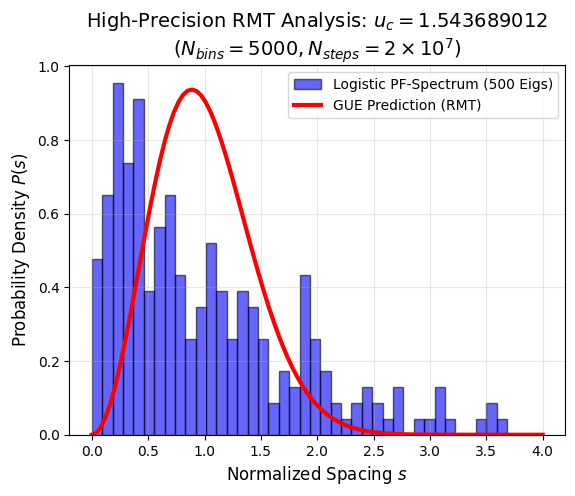

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs

def analyze_high_precision_rmt(u, n_bins=5000, n_steps=1*10**9, k_eig=500):
    """
    Higher precision RMT analysis for the autonomous system.
    """
    # 1. Generate orbit
    x = 0.5
    # Pre-run to settle on attractor
    for _ in range(10000):
        x = 1 - u * x**2
        
    orbit = np.zeros(n_steps)
    for i in range(n_steps):
        x = 1 - u * x**2
        orbit[i] = x
    
    # 2. Construct P-F Matrix
    x_min, x_max = -1.0, 1.0
    # Map orbit to bins
    bins = ((orbit - x_min) / (x_max - x_min) * n_bins).astype(int)
    # Ensure indices are within [0, n_bins-1]
    bins = np.clip(bins, 0, n_bins - 1)
    
    # Build sparse matrix
    row = bins[:-1]
    col = bins[1:]
    data = np.ones(len(row))
    P = csr_matrix((data, (row, col)), shape=(n_bins, n_bins))
    
    # Row normalization
    row_sums = np.array(P.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0
    P = P.multiply(1.0 / row_sums[:, np.newaxis])
    
    # 3. Extract Eigenvalues
    # Extract 500 eigenvalues
    vals, _ = eigs(P, k=k_eig, which='LM', tol=1e-4)
    
    # 4. Extract Phases and Compute Spacings
    # Filter: focus on eigenvalues on/near the unit circle (significant modes)
    # and in the upper half plane to avoid duplicate conjugate pairs.
    significant_vals = vals[np.abs(vals) > 0.5]
    phases = np.angle(significant_vals)
    # We take only positive phases to avoid conjugate symmetry redundancy
    phases = np.sort(phases[phases > 0])
    
    # Nearest Neighbor Spacings
    spacings = np.diff(phases)
    # Normalize: mean spacing = 1
    s = spacings / np.mean(spacings)
    
    # 5. Plotting
    plt.hist(s, bins=40, density=True, alpha=0.6, color='blue', edgecolor='black', label='Logistic PF-Spectrum (500 Eigs)')
    
    # GUE Theoretical Curve (Wigner Surmise)
    s_theory = np.linspace(0, 4, 100)
    p_gue = (32 / np.pi**2) * (s_theory**2) * np.exp(-4 * s_theory**2 / np.pi)
    plt.plot(s_theory, p_gue, 'r-', lw=3, label='GUE Prediction (RMT)')
    
    plt.title(f'High-Precision RMT Analysis: $u_c = {u}$\n($N_{{bins}}=5000, N_{{steps}}=2\\times 10^7$)', fontsize=14)
    plt.xlabel('Normalized Spacing $s$', fontsize=12)
    plt.ylabel('Probability Density $P(s)$', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Save the plot
    plt.savefig('high_precision_rmt_plot.png')
    
    # Print some statistics for interpretation
    mean_s = np.mean(s)
    std_s = np.std(s)
    return mean_s, std_s, len(s)

# Run with user's parameters
u_c = 1.543689012
mean_val, std_val, count = analyze_high_precision_rmt(u_c)
print(f"Mean spacing: {mean_val}")
print(f"Std deviation: {std_val}")
print(f"Number of spacings: {count}")